In [3]:
import torch
print(torch.__version__)

2.11.0+cpu


In [4]:
import torch
print(torch.cuda.is_available())

False


In [5]:
import torch
import torch.nn as nn
import torch.optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [6]:
dt = pd.read_csv(r"BostonHousing.csv")

In [7]:
dt.shape

(506, 14)

> 506 rows 14 features

In [8]:
dt.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='str')

In [9]:
X = dt.drop(columns="medv")
Y = dt.medv

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [11]:
X_train.shape

(404, 13)

In [12]:
X_test.shape

(102, 13)

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [15]:
class DNNModel(nn.Module):
    def __init__(self):
        super(DNNModel, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(13, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)   # Output layer (Regression)
        )

    def forward(self, x):
        return self.model(x)

In [16]:
model = DNNModel()

In [17]:
criterion = nn.MSELoss()   
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [18]:
epochs = 100

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 447.0776
Epoch [20/100], Loss: 140.8198
Epoch [30/100], Loss: 46.3712
Epoch [40/100], Loss: 30.7164
Epoch [50/100], Loss: 19.6025
Epoch [60/100], Loss: 16.8850
Epoch [70/100], Loss: 14.8133
Epoch [80/100], Loss: 13.3684
Epoch [90/100], Loss: 12.1566
Epoch [100/100], Loss: 11.4347


In [19]:
model.eval()

with torch.no_grad():
    predictions = model(X_test)
    test_loss = criterion(predictions, y_test)

print("Test Loss:", test_loss.item())

Test Loss: 13.499483108520508


In [20]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test.numpy(), predictions.numpy())
print("R2 Score:", r2)

R2 Score: 0.8159172534942627


In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_true = y_test.detach().numpy()
y_pred = predictions.detach().numpy()

# MSE
mse = mean_squared_error(y_true, y_pred)

# RMSE
rmse = np.sqrt(mse)

# MAE
mae = mean_absolute_error(y_true, y_pred)

# R2 Score
r2 = r2_score(y_true, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 13.499484062194824
RMSE: 3.674164403261621
MAE: 2.3521761894226074
R2 Score: 0.8159172534942627


In [22]:
losses = []

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

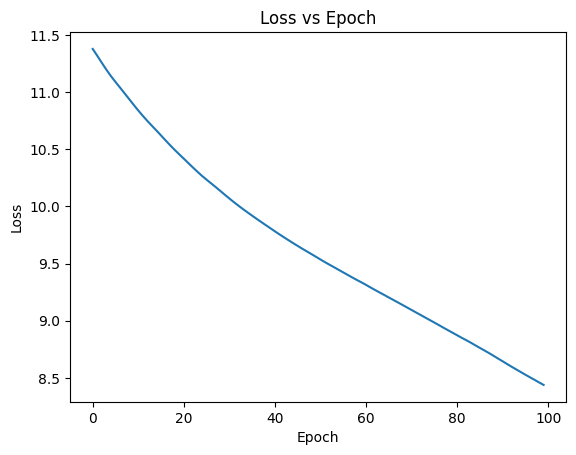

In [23]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.show()

In [24]:
for i in range(10):
    print(f"Actual: {y_true[i][0]:.2f} | Predicted: {y_pred[i][0]:.2f}")

Actual: 23.60 | Predicted: 27.76
Actual: 32.40 | Predicted: 33.42
Actual: 13.60 | Predicted: 19.21
Actual: 22.80 | Predicted: 27.13
Actual: 16.10 | Predicted: 16.82
Actual: 20.00 | Predicted: 20.73
Actual: 17.80 | Predicted: 15.17
Actual: 14.00 | Predicted: 14.28
Actual: 19.60 | Predicted: 24.09
Actual: 16.80 | Predicted: 16.82


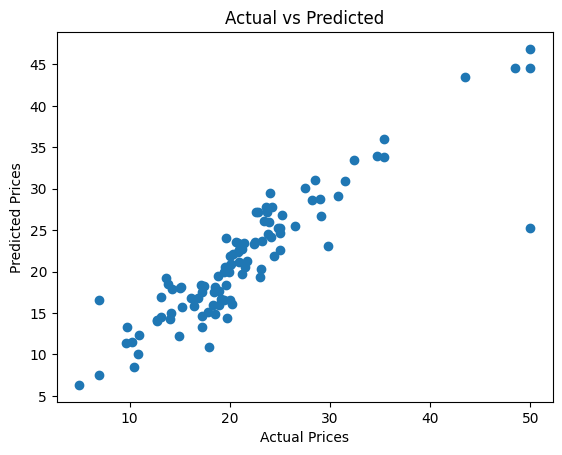

In [25]:
plt.scatter(y_true, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()